In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
import random
from collections import Counter
from pathlib import Path

import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

print("PyTorch version:", torch.__version__)
print("All libraries imported successfully!")

PyTorch version: 2.11.0+cpu
All libraries imported successfully!


In [2]:
DATASET_PATH = 'C:/Users/Lenovo/Desktop/color'

print("Dataset Path:", DATASET_PATH)
print("Path exists:", os.path.exists(DATASET_PATH))

Dataset Path: C:/Users/Lenovo/Desktop/color
Path exists: True


In [3]:
class_names = sorted(os.listdir(DATASET_PATH))
class_counts = {}

for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        class_counts[cls] = count

print(f"Total Classes : {len(class_counts)}")
print(f"Total Images  : {sum(class_counts.values())}")
print()
for cls, count in class_counts.items():
    print(f"  {cls:<60} {count} images")

Total Classes : 38
Total Images  : 54305

  Apple___Apple_scab                                           630 images
  Apple___Black_rot                                            621 images
  Apple___Cedar_apple_rust                                     275 images
  Apple___healthy                                              1645 images
  Blueberry___healthy                                          1502 images
  Cherry_(including_sour)___Powdery_mildew                     1052 images
  Cherry_(including_sour)___healthy                            854 images
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot           513 images
  Corn_(maize)___Common_rust_                                  1192 images
  Corn_(maize)___Northern_Leaf_Blight                          985 images
  Corn_(maize)___healthy                                       1162 images
  Grape___Black_rot                                            1180 images
  Grape___Esca_(Black_Measles)                                 1

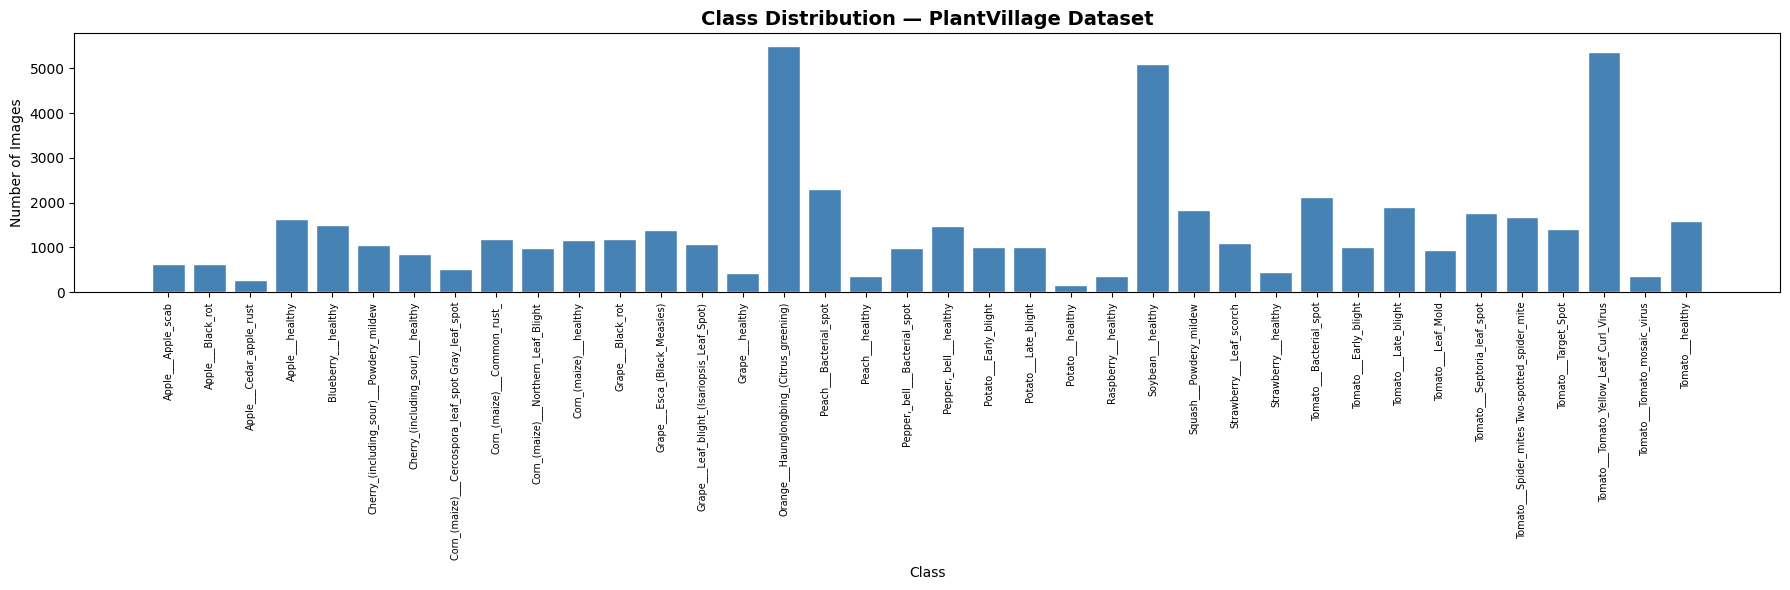

Saved: class_distribution.png


In [4]:
plt.figure(figsize=(18, 6))
plt.bar(range(len(class_counts)), list(class_counts.values()), color='steelblue', edgecolor='white')
plt.xticks(range(len(class_counts)), list(class_counts.keys()), rotation=90, fontsize=7)
plt.title('Class Distribution — PlantVillage Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Saved: class_distribution.png")

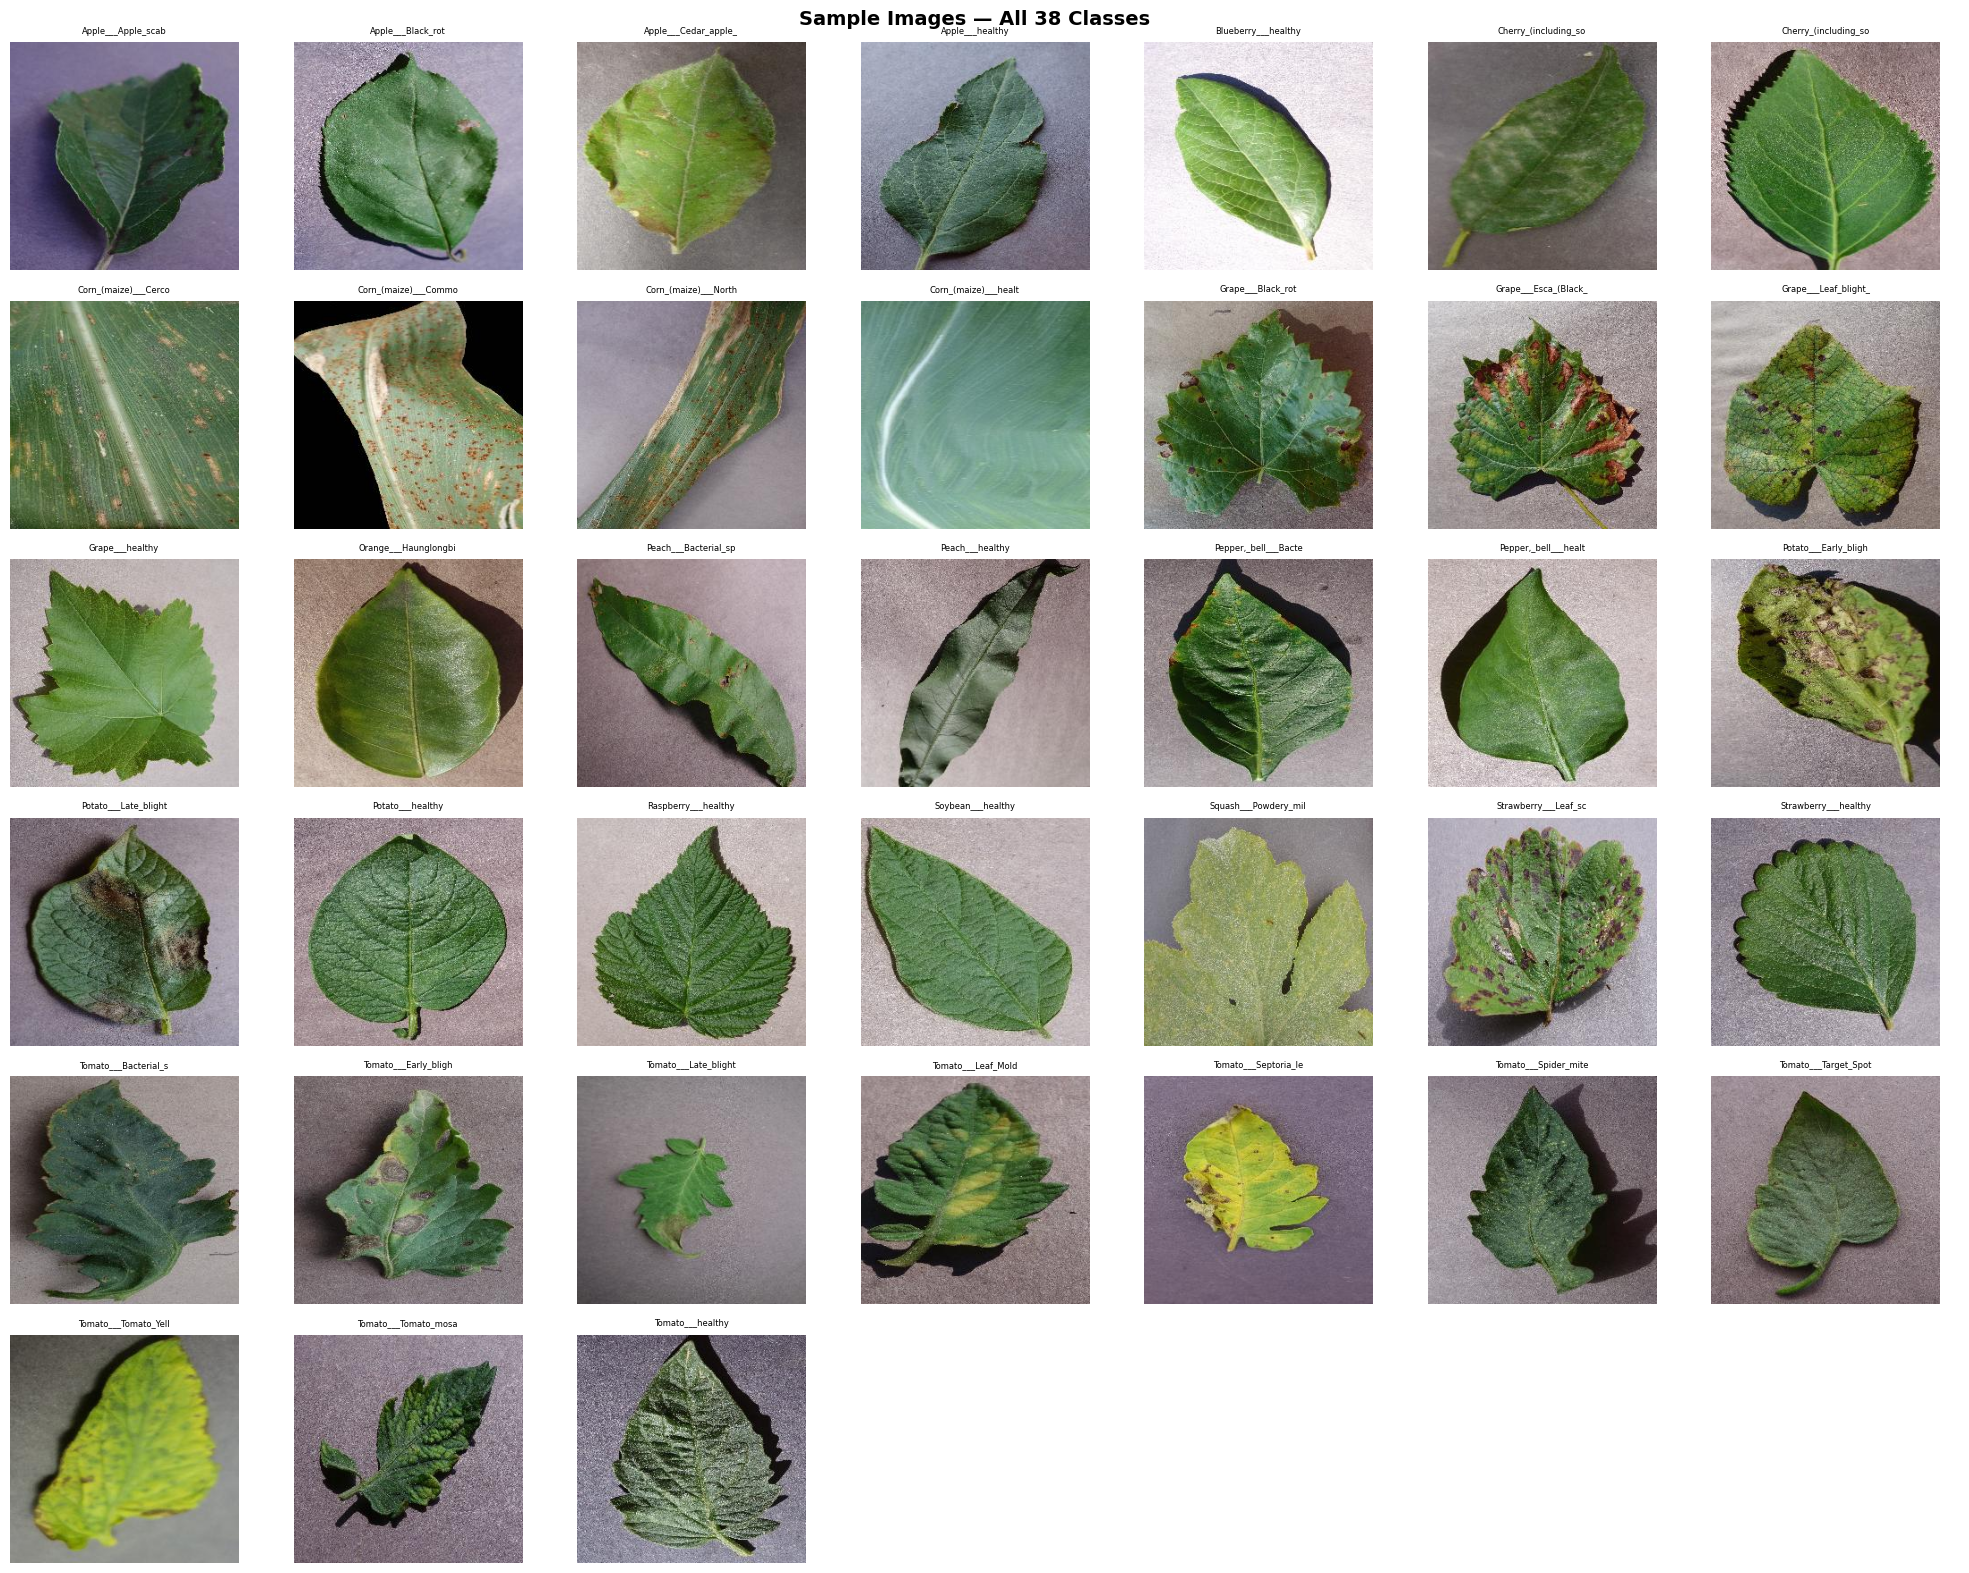

Saved: sample_images.png


In [6]:
fig, axes = plt.subplots(6, 7, figsize=(20, 16))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    images = os.listdir(cls_path)
    img_path = os.path.join(cls_path, random.choice(images))
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls[:20], fontsize=6)
    axes[i].axis('off')

# Hide any extra subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images — All 38 Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
print("Saved: sample_images.png")

In [ ]:
corrupted_files = []
valid_count = 0

for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        try:
            img = Image.open(fpath)
            img.verify()
            valid_count += 1
        except Exception as e:
            corrupted_files.append((fpath, str(e)))

print(f"Valid Images   : {valid_count}")
print(f"Corrupted      : {len(corrupted_files)}")

if corrupted_files:
    print("\nCorrupted Files:")
    for path, err in corrupted_files:
        print(f"  {path} — {err}")
else:
    print("No corrupted files found! Dataset is clean ✅")

In [7]:
size_counter = Counter()
all_images = []

for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_images.append(os.path.join(cls_path, f))

random.shuffle(all_images)
for fpath in all_images[:300]:
    try:
        img = Image.open(fpath)
        size_counter[img.size] += 1
    except:
        pass

print("Image Size Distribution (sample of 300):")
for size, count in size_counter.most_common(10):
    print(f"  {size} → {count} images")

Image Size Distribution (sample of 300):
  (256, 256) → 300 images


In [8]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15

print(f"Image Size      : {IMG_SIZE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Train Split     : {TRAIN_SPLIT}")
print(f"Val Split       : {VAL_SPLIT}")
print(f"Test Split      : {TEST_SPLIT}")

Image Size      : (224, 224)
Batch Size      : 32
Train Split     : 0.7
Val Split       : 0.15
Test Split      : 0.15


In [9]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

# Split 70/15/15
total      = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_data, val_data, test_data = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

print(f"Total  : {total}")
print(f"Train  : {train_size}")
print(f"Val    : {val_size}")
print(f"Test   : {test_size}")

Total  : 54305
Train  : 38013
Val    : 8145
Test   : 8147


In [10]:
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)   # (32, 3, 224, 224)
print("Batch label shape:", labels.shape)   # (32,)
print("Pixel min:", images.min().item())
print("Pixel max:", images.max().item())

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Pixel min: -2.1007792949676514
Pixel max: 2.640000104904175


In [11]:
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Pixel min:", images.min().item())
print("Pixel max:", images.max().item())

print("\nClass Names:")
for cls, idx in full_dataset.class_to_idx.items():
    print(f"  {idx:>2} — {cls}")

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Pixel min: -2.1007792949676514
Pixel max: 2.4482791423797607

Class Names:
   0 — Apple___Apple_scab
   1 — Apple___Black_rot
   2 — Apple___Cedar_apple_rust
   3 — Apple___healthy
   4 — Blueberry___healthy
   5 — Cherry_(including_sour)___Powdery_mildew
   6 — Cherry_(including_sour)___healthy
   7 — Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   8 — Corn_(maize)___Common_rust_
   9 — Corn_(maize)___Northern_Leaf_Blight
  10 — Corn_(maize)___healthy
  11 — Grape___Black_rot
  12 — Grape___Esca_(Black_Measles)
  13 — Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  14 — Grape___healthy
  15 — Orange___Haunglongbing_(Citrus_greening)
  16 — Peach___Bacterial_spot
  17 — Peach___healthy
  18 — Pepper,_bell___Bacterial_spot
  19 — Pepper,_bell___healthy
  20 — Potato___Early_blight
  21 — Potato___Late_blight
  22 — Potato___healthy
  23 — Raspberry___healthy
  24 — Soybean___healthy
  25 — Squash___P